# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Performance Finalscore Dataset](https://www.kaggle.com/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset/data?select=student_performance_finalscore.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_performance_finalscore.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
7995,STU07996,18,Female,6.45,93.6,9.7,5.4,5.9,3.28,No,Online,Poor,Excellent,Yes,3,Middle,3.8,98.58
7996,STU07997,20,Non-Binary,0.80,94.4,7.6,6.7,2.2,3.73,Yes,Offline,Poor,Good,Yes,2,Middle,4.5,72.58
7997,STU07998,19,Female,3.76,96.4,6.8,6.9,3.1,1.81,No,Hybrid,Poor,Good,No,0,Low,2.2,63.95
7998,STU07999,20,Female,3.87,79.2,8.2,8.2,4.9,3.36,No,Hybrid,Good,Excellent,Yes,2,Low,3.1,85.19
7999,STU08000,23,Female,6.87,74.5,4.9,2.0,2.4,2.48,Yes,Offline,Good,Good,Yes,3,Middle,3.0,97.50


## Shape of our dataset

In [5]:
df.shape

(8000, 18)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Hours_Studied', 'Attendance',
       'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA',
       'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality',
       'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level',
       'Exam_Anxiety_Score', 'Final_Score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                     object
Age                             int64
Gender                         object
Hours_Studied                 float64
Attendance                    float64
Sleep_Hours                   float64
Stress_Level                  float64
Screen_Time                   float64
Previous_GPA                  float64
Part_Time_Job                  object
Study_Method                   object
Diet_Quality                   object
Internet_Quality               object
Extracurricular                object
Tutoring_Sessions_Per_Week      int64
Family_Income_Level            object
Exam_Anxiety_Score            float64
Final_Score                   float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   object 
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   object 
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   object 
 10  Study_Method                8000 non-null   object 
 11  Diet_Quality                8000 non-null   object 
 12  Internet_Quality            8000 non-null   object 
 13  Extracurricular             8000 

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

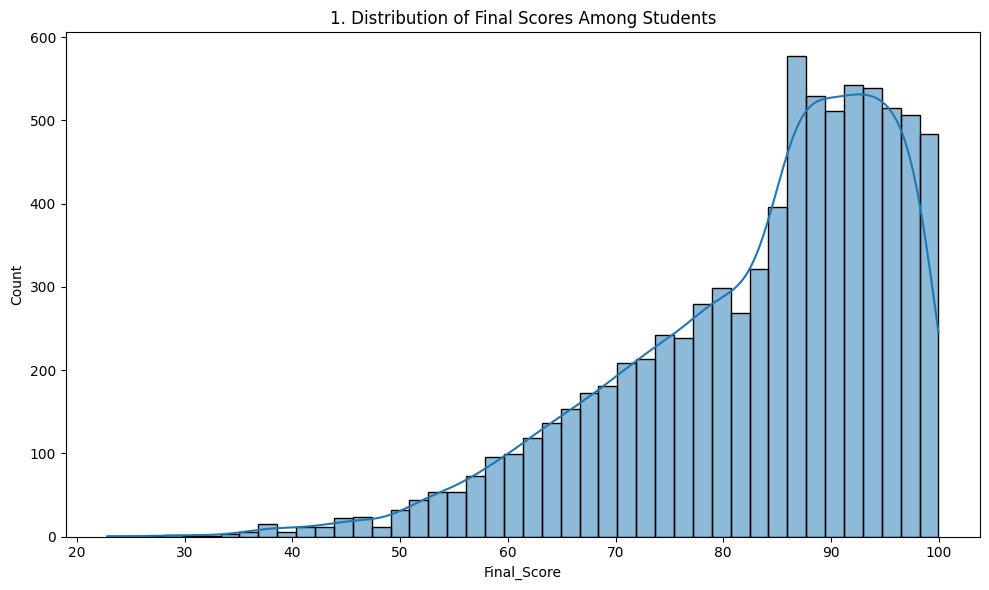

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Final_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Final Scores Among Students')
show_fig()
plot_no += 1

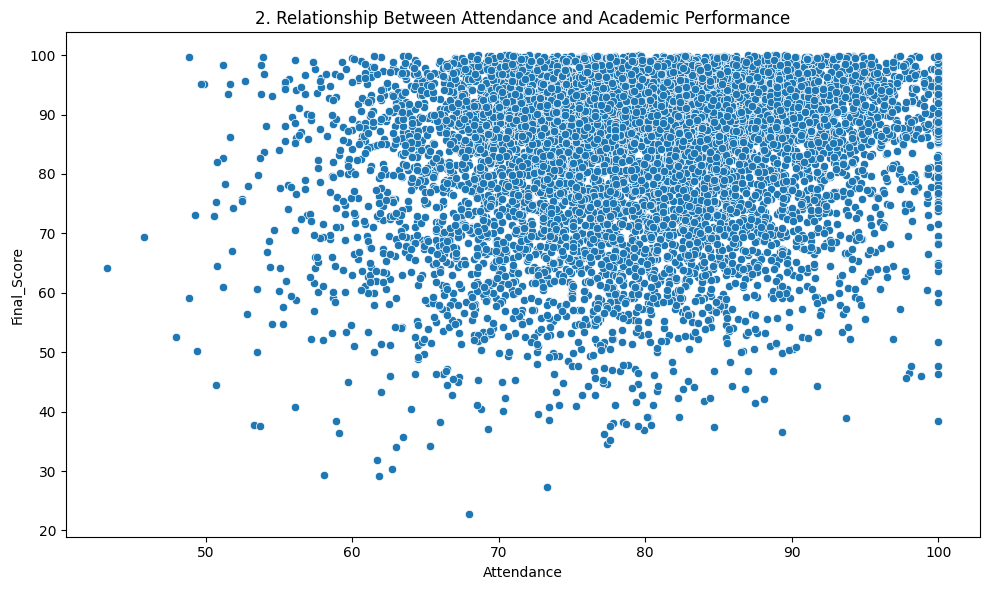

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Attendance', y='Final_Score', data=df)
plt.title(f'{plot_no}. Relationship Between Attendance and Academic Performance')
show_fig()
plot_no += 1

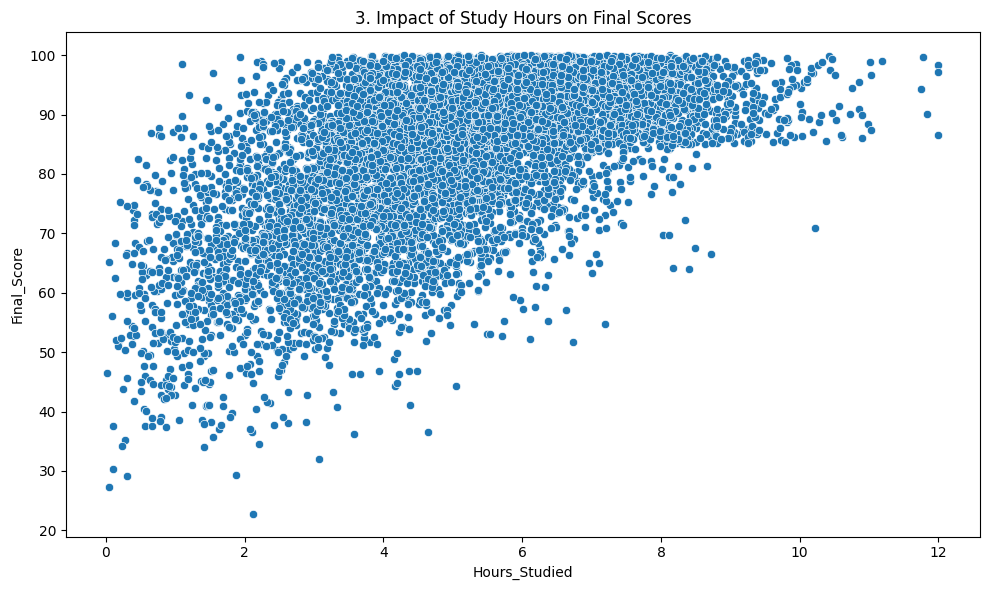

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Hours_Studied', y='Final_Score', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on Final Scores')
show_fig()
plot_no += 1

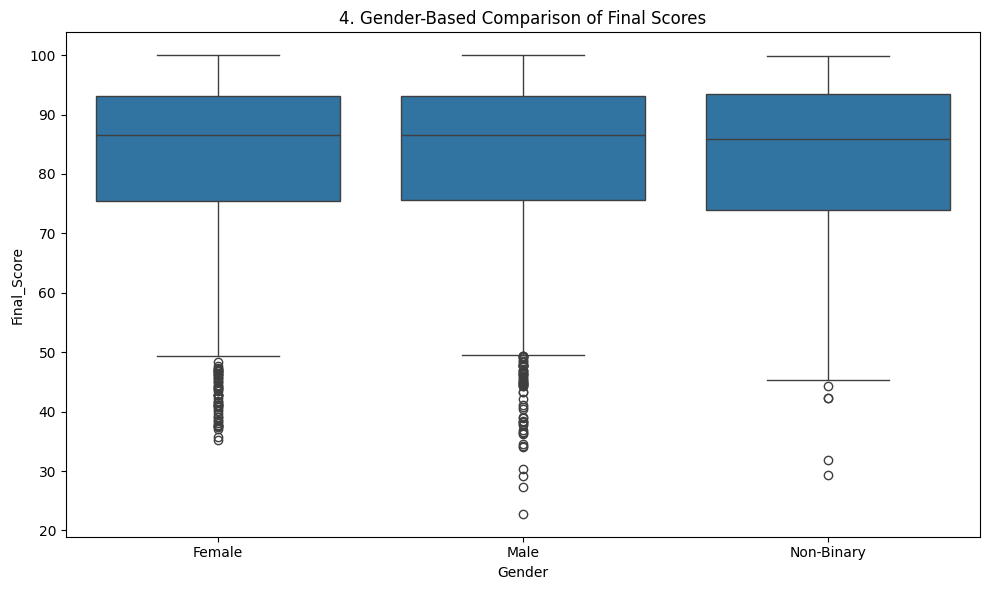

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Gender', y='Final_Score', data=df)
plt.title(f'{plot_no}. Gender-Based Comparison of Final Scores')
show_fig()
plot_no += 1

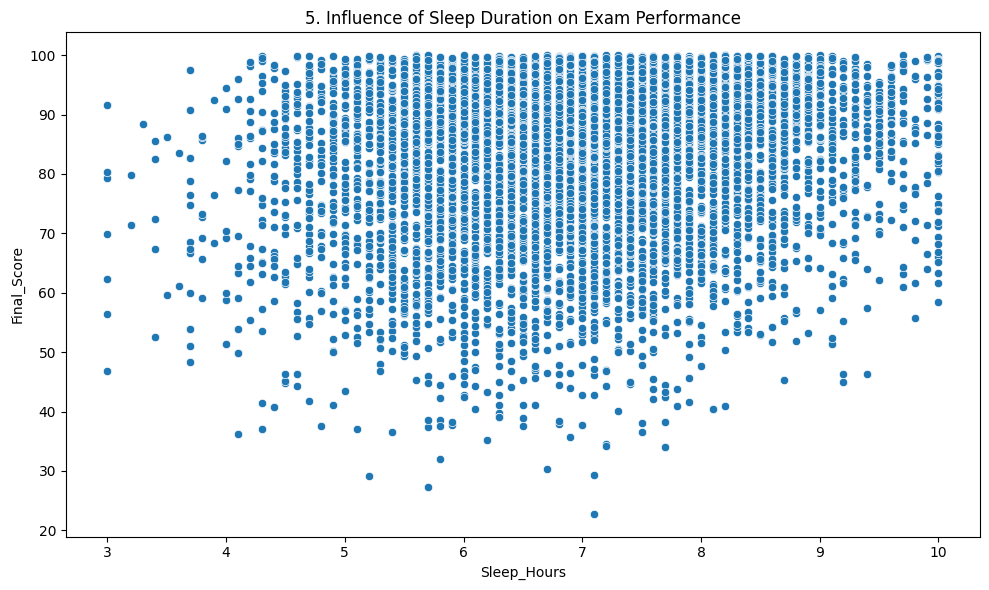

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sleep_Hours', y='Final_Score', data=df)
plt.title(f'{plot_no}. Influence of Sleep Duration on Exam Performance')
show_fig()
plot_no += 1

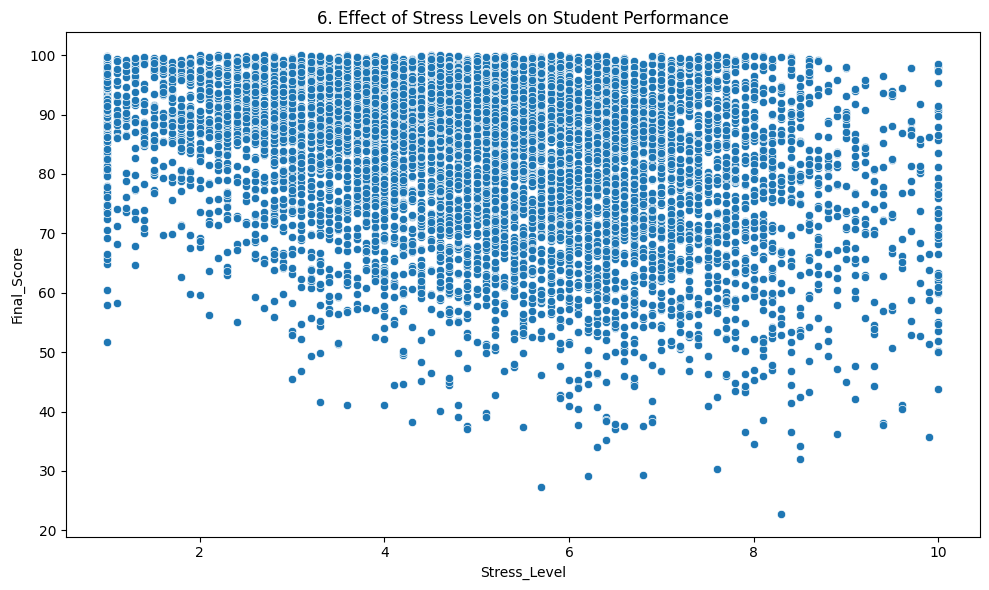

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Stress_Level', y='Final_Score', data=df)
plt.title(f'{plot_no}. Effect of Stress Levels on Student Performance')
show_fig()
plot_no += 1

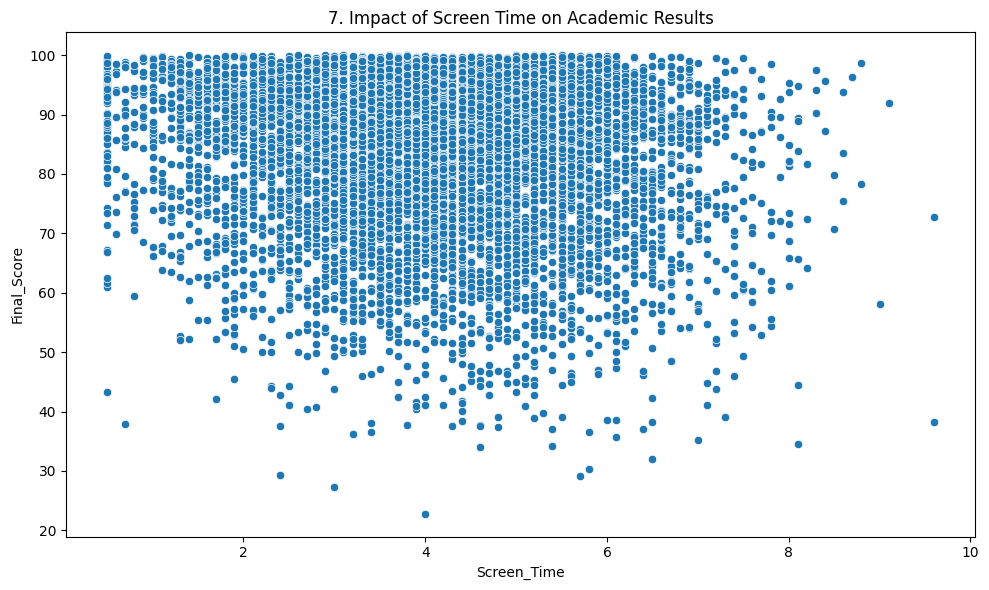

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Screen_Time', y='Final_Score', data=df)
plt.title(f'{plot_no}. Impact of Screen Time on Academic Results')
show_fig()
plot_no += 1

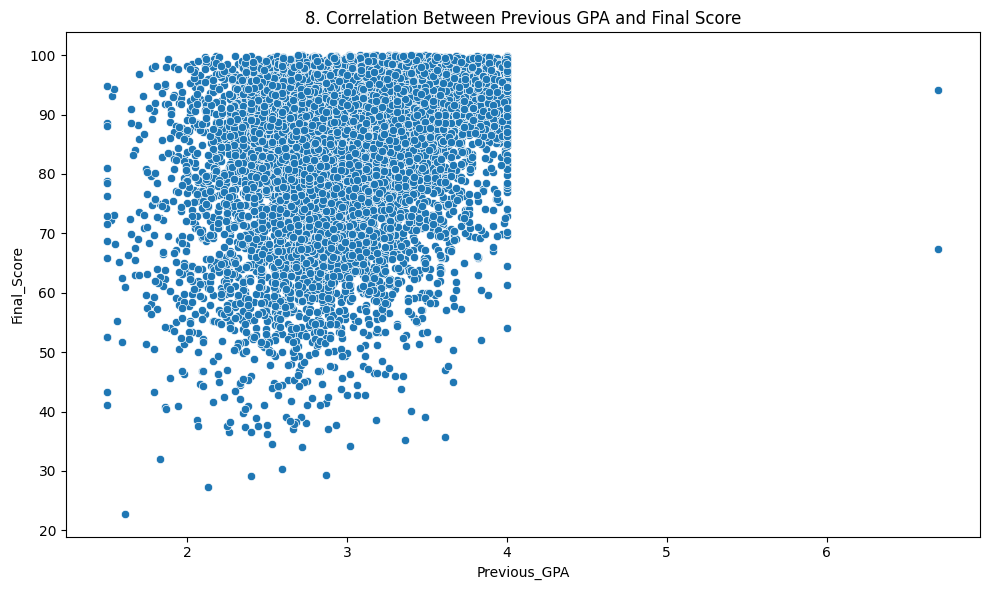

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Previous_GPA', y='Final_Score', data=df)
plt.title(f'{plot_no}. Correlation Between Previous GPA and Final Score')
show_fig()
plot_no += 1

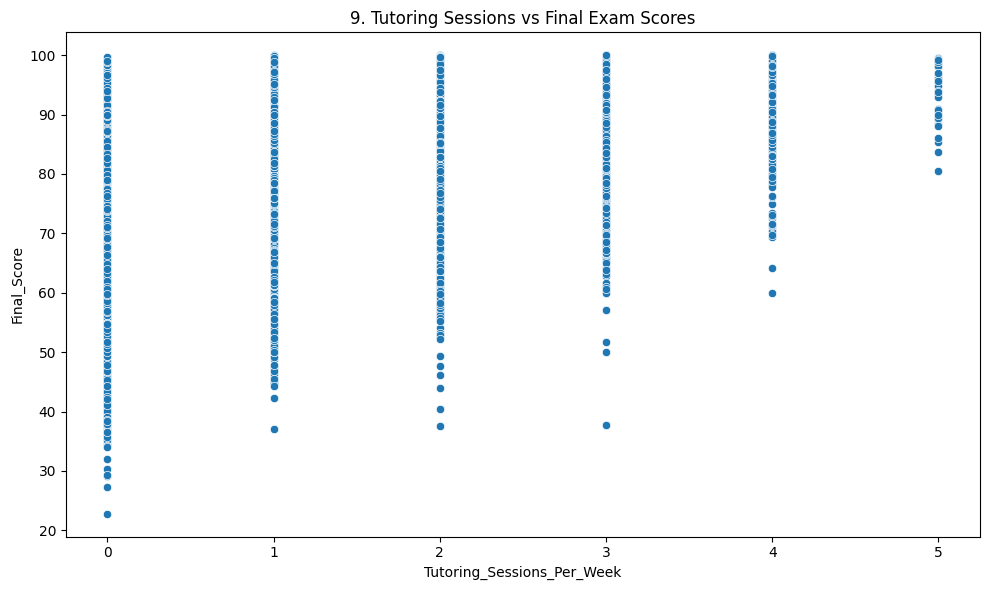

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Tutoring_Sessions_Per_Week', y='Final_Score', data=df)
plt.title(f'{plot_no}. Tutoring Sessions vs Final Exam Scores')
show_fig()
plot_no += 1

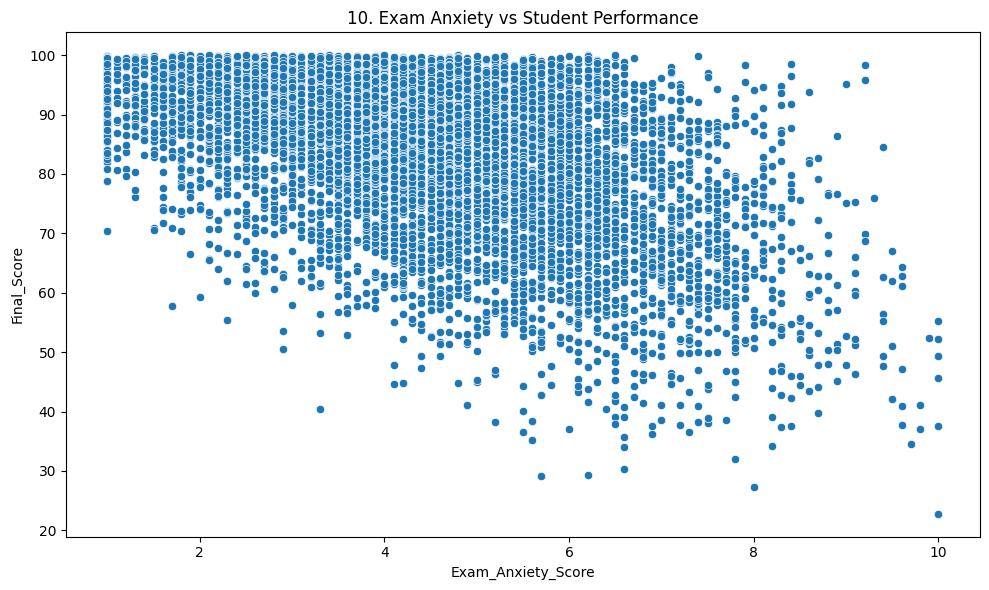

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Exam_Anxiety_Score', y='Final_Score', data=df)
plt.title(f'{plot_no}. Exam Anxiety vs Student Performance')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

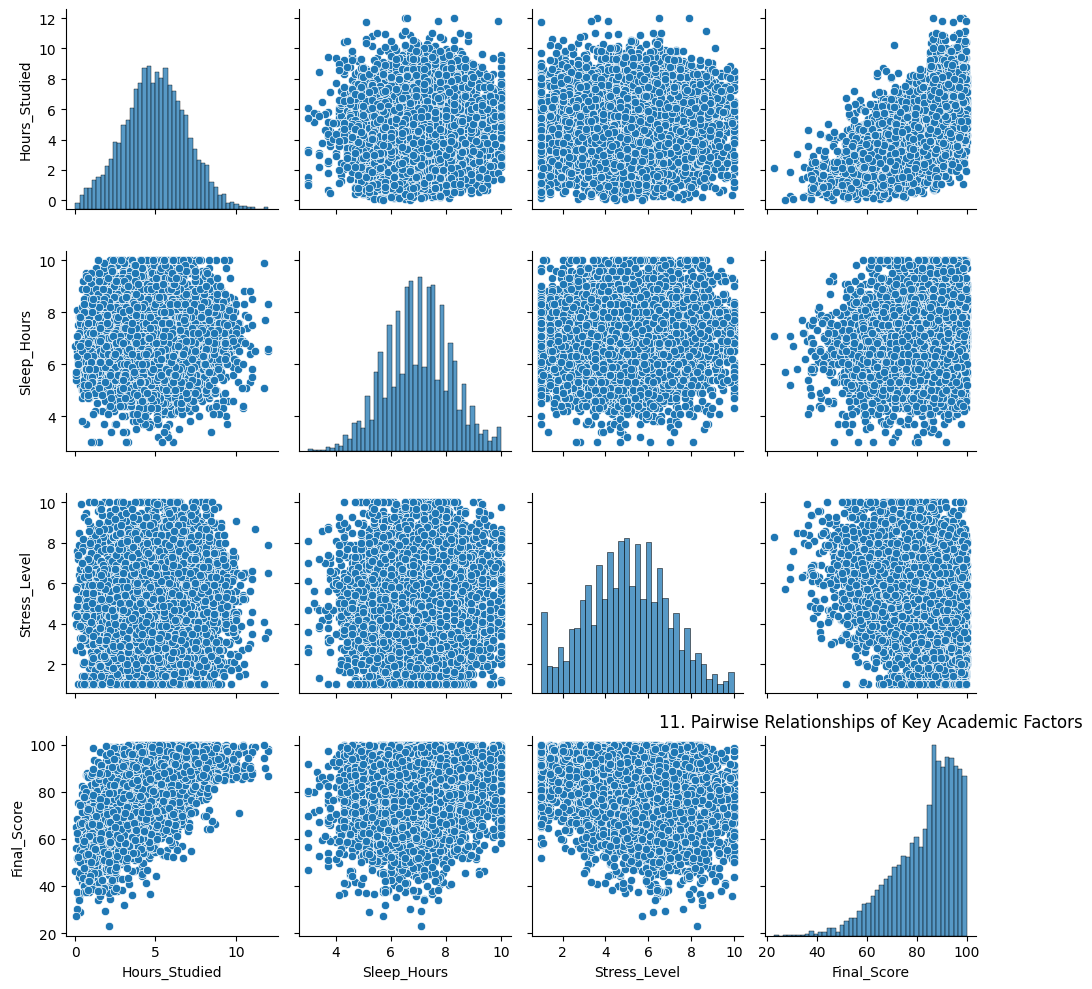

In [23]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['Hours_Studied','Sleep_Hours','Stress_Level','Final_Score']])
plt.title(f'{plot_no}. Pairwise Relationships of Key Academic Factors')
show_fig()
plot_no += 1

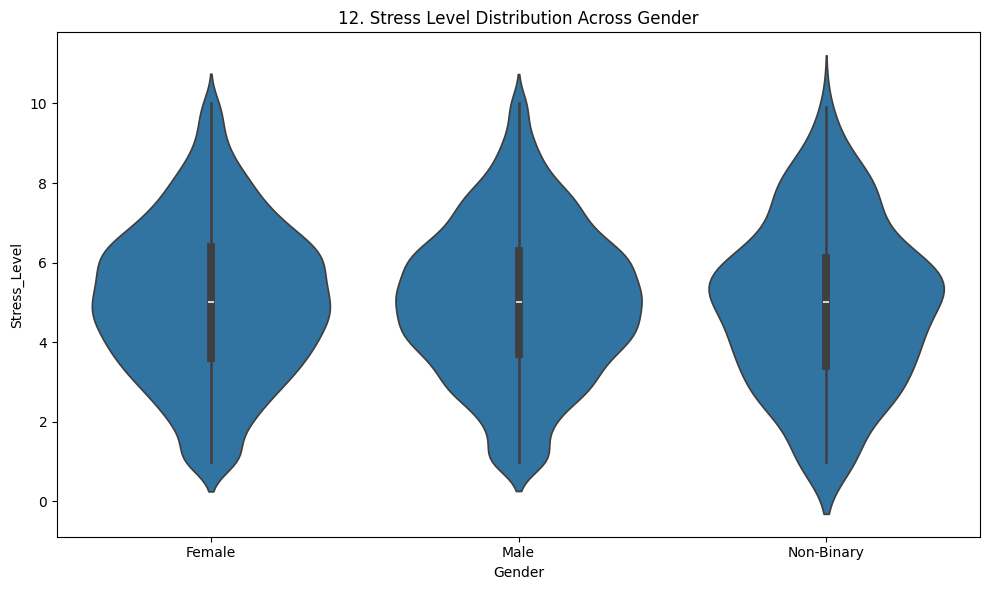

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Gender', y='Stress_Level', data=df)
plt.title(f'{plot_no}. Stress Level Distribution Across Gender')
show_fig()
plot_no += 1

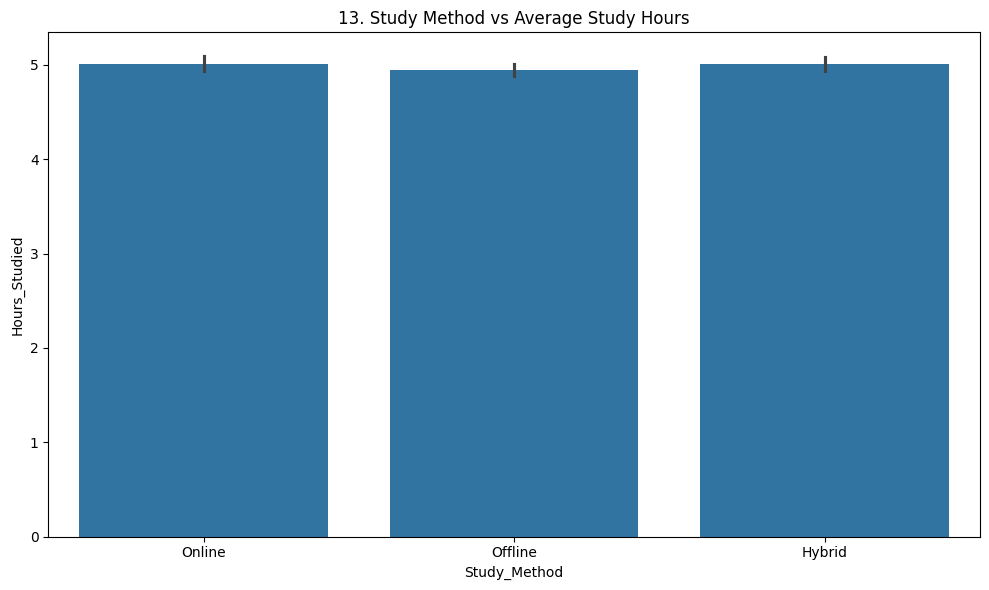

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Study_Method', y='Hours_Studied', data=df)
plt.title(f'{plot_no}. Study Method vs Average Study Hours')
show_fig()
plot_no += 1

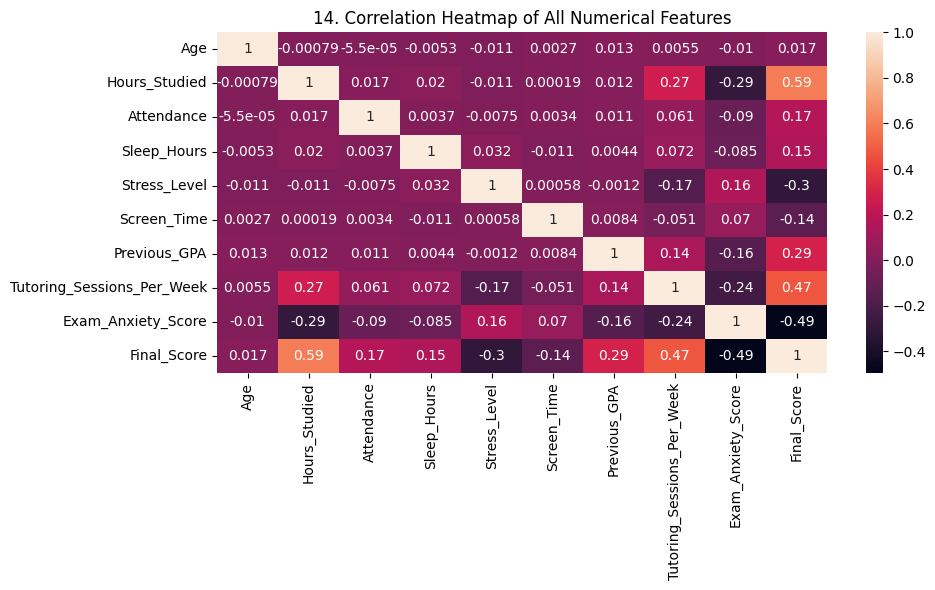

In [26]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## drop non-useful column

In [27]:
df_model = df.drop(columns=['Student_ID'])

## feature engineering

In [28]:
df_model['Study_Efficiency'] = df_model['Hours_Studied'] / (df_model['Stress_Level'] + 1)
df_model['Productivity'] = df_model['Hours_Studied'] * df_model['Attendance']
df_model['Mental_Impact'] = df_model['Stress_Level'] + df_model['Exam_Anxiety_Score']

## remove weak features

In [29]:
df_model = df_model.drop(columns=['Age','Screen_Time','Sleep_Hours'])

## convert categorical to numeric

In [30]:
df_model = pd.get_dummies(df_model, drop_first=True)

## define features and target

In [31]:
X = df_model.drop('Final_Score', axis=1)
y = df_model['Final_Score']

## split dataset

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train improved model

In [34]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


## predictions

In [35]:
y_pred = model.predict(X_test)

## accuracy score

In [36]:
score = r2_score(y_test, y_pred)
print("Improved Model Accuracy (R2 Score):", score)

Improved Model Accuracy (R2 Score): 0.7232231708866975


## plot actual vs predicted

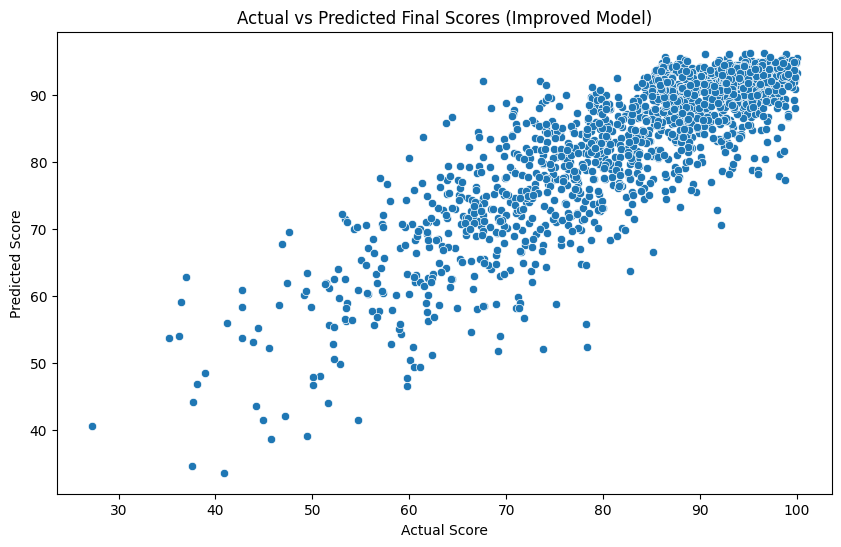

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Scores (Improved Model)")
plt.show()